# Machine Learning Project 3 Group 5

#### Chisa Waku: 300358628
#### Gustavo Reis: 300356110
#### Haichuan Li: 300376709
#### Xinyu Wei: 300365127
#### Yuen San Keung: 300356894

# Introduction

## Features description

Original dataset of Heart Attack Analysis & Prediction Dataset contains the following features. 
- age - age of the patient
- sex - Sex of the patient
- cp : Chest Pain type chest pain type  
  - Value 1: typical angina  
  - Value 2: atypical angina  
  - Value 3: non-anginal pain  
  - Value 4: asymptomatic  
- trtbps - resting blood pressure (in mm Hg)
- chol - cholestoral in mg/dl fetched via BMI sensor
- fbs - (fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
- restecg - resting electrocardiographic results
  - Value 0: normal
  - Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
  - Value 2: showing probable or definite left ventricular hypertrophy by Estes' criteria
- thalachh - maximum heart rate achieved
- exng - exercise induced angina (1 = yes; 0 = no)
- oldpeak - Previous peak
- slope - the slope of the peak exercise ST segment
  - Value 1: unsloping  
  - Value 2: flat  
  - Value 3: downsloping  
- caa - number of major vessels (0-3)
- thall - thalassemia
  - Value 0: typical angina  
  - Value 1: atypical angina  
  - Value 2: non-anginal pain  
  - Value 3: asymptomatic
- output - diagnosis of heart attack
  - Value 0: < 50% diameter narrowing. less chance of heart attack
  - Value 1: > 50% diameter narrowing. more chance of heart attack

# Data Preparation

In [1]:
# Importing Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime as dt
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# loading the data set
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# Translating features
df=df.rename(columns={'cp':'chest_pain',
                      'trtbps':'resting_BP',
                      'chol':'cholestoral',
                      'fbs':'fasting_blood_sugar',
                      'restecg':'resting_ECG',
                      'thalachh':'max_heart_rate',
                      'exng':'exercise_induced_angina',
                      'slp':'slope_type',
                      'caa':"number_of_major_vessels",
                      'thall':'thalassemia',
                      'oldpeak':'previous_peak'})
df

,age,sex,chest_pain,resting_BP,cholestoral,fasting_blood_sugar,resting_ECG,max_heart_rate,exercise_induced_angina,previous_peak,slope_type,number_of_major_vessels,thalassemia,output
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [4]:
# Checking the shape
df.shape

(303, 14)

In [5]:
# Checking information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      303 non-null    int64  
 1   sex                      303 non-null    int64  
 2   chest_pain               303 non-null    int64  
 3   resting_BP               303 non-null    int64  
 4   cholestoral              303 non-null    int64  
 5   fasting_blood_sugar      303 non-null    int64  
 6   resting_ECG              303 non-null    int64  
 7   max_heart_rate           303 non-null    int64  
 8   exercise_induced_angina  303 non-null    int64  
 9   previous_peak            303 non-null    float64
 10  slope_type               303 non-null    int64  
 11  number_of_major_vessels  303 non-null    int64  
 12  thalassemia              303 non-null    int64  
 13  output                   303 non-null    int64  
dtypes: float64(1), int64(13)
m

In [6]:
# Checking null values
df.isnull().sum()

age                        0
sex                        0
chest_pain                 0
resting_BP                 0
cholestoral                0
fasting_blood_sugar        0
resting_ECG                0
max_heart_rate             0
exercise_induced_angina    0
previous_peak              0
slope_type                 0
number_of_major_vessels    0
thalassemia                0
output                     0
dtype: int64

In [7]:
# Checking duplicated values
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
298    False
299    False
300    False
301    False
302    False
Length: 303, dtype: bool

In [8]:
# Checking unique values
dict = {}
for i in list(df):
    dict[i] = df[i].value_counts().shape[0]

pd.DataFrame(dict,index=["unique count"]).transpose()

,unique count
age,41
sex,2
chest_pain,4
resting_BP,49
cholestoral,152
fasting_blood_sugar,2
resting_ECG,3
max_heart_rate,91
exercise_induced_angina,2
previous_peak,40


In [9]:
# Separating continuous, categorical and target columns
continuous = ["age","resting_BP","cholestoral","max_heart_rate","previous_peak"]
categorical = ['sex','exercise_induced_angina','number_of_major_vessels','chest_pain',
               'fasting_blood_sugar','resting_ECG','slope_type','thalassemia']
target = ["output"]
print("The continuous cols are : ", continuous)
print("The categorial cols are : ", categorical)
print("The target variable is :  ", target)

The continuous cols are :  ['age', 'resting_BP', 'cholestoral', 'max_heart_rate', 'previous_peak']
The categorial cols are :  ['sex', 'exercise_induced_angina', 'number_of_major_vessels', 'chest_pain', 'fasting_blood_sugar', 'resting_ECG', 'slope_type', 'thalassemia']
The target variable is :   ['output']


# Data Visualization

<AxesSubplot:xlabel='sex', ylabel='count'>

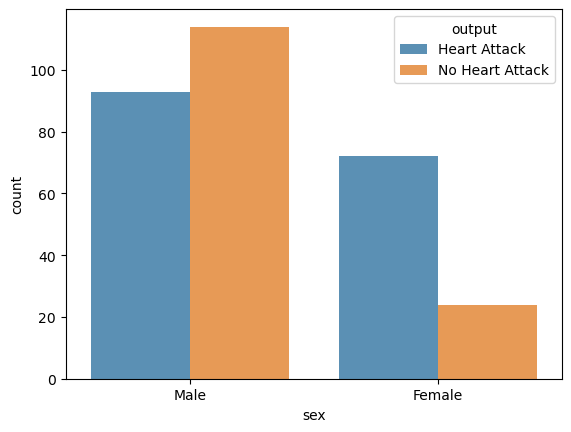

In [10]:
# Translating 0 as No Heart Attack and 1 as Heart Attack
def disease(x):
    if x == 0:
        return 'No Heart Attack'
    else:
        return 'Heart Attack'

# Tranlating 0 as Female and 1 as Male
def gender(sex):
    if sex == 0:
        return 'Female'
    else:
        return 'Male'
    
# Applying translations to the data set
df1 = df.copy()
df1['output'] = df1['output'].apply(disease)
df1['sex'] = df1['sex'].apply(gender)
    
# Countplot of males vs females considering heart diseases

sns.countplot(x ='sex', data = df1, hue='output', alpha=.8, linewidth=0)

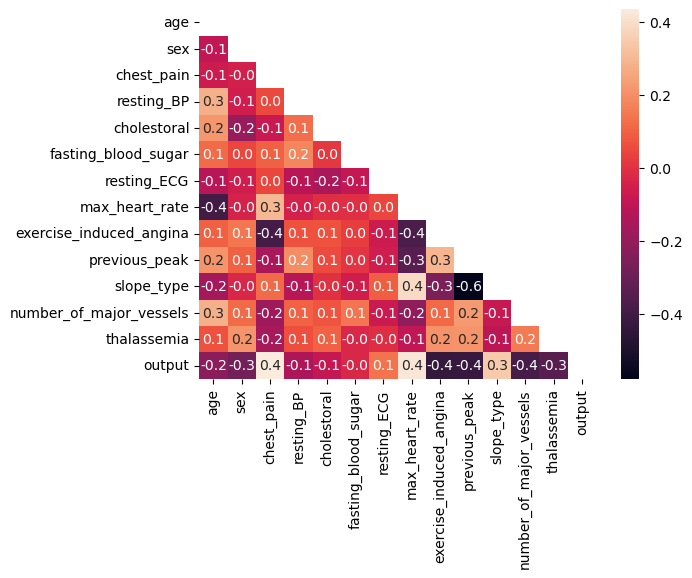

In [11]:
# Correlation Matrix
df_corr = df.corr().transpose()
mask = np.triu(np.ones_like(df_corr))
sns.heatmap(df_corr,mask=mask,fmt=".1f",annot=True)
plt.show()

<AxesSubplot:xlabel='previous_peak', ylabel='Density'>

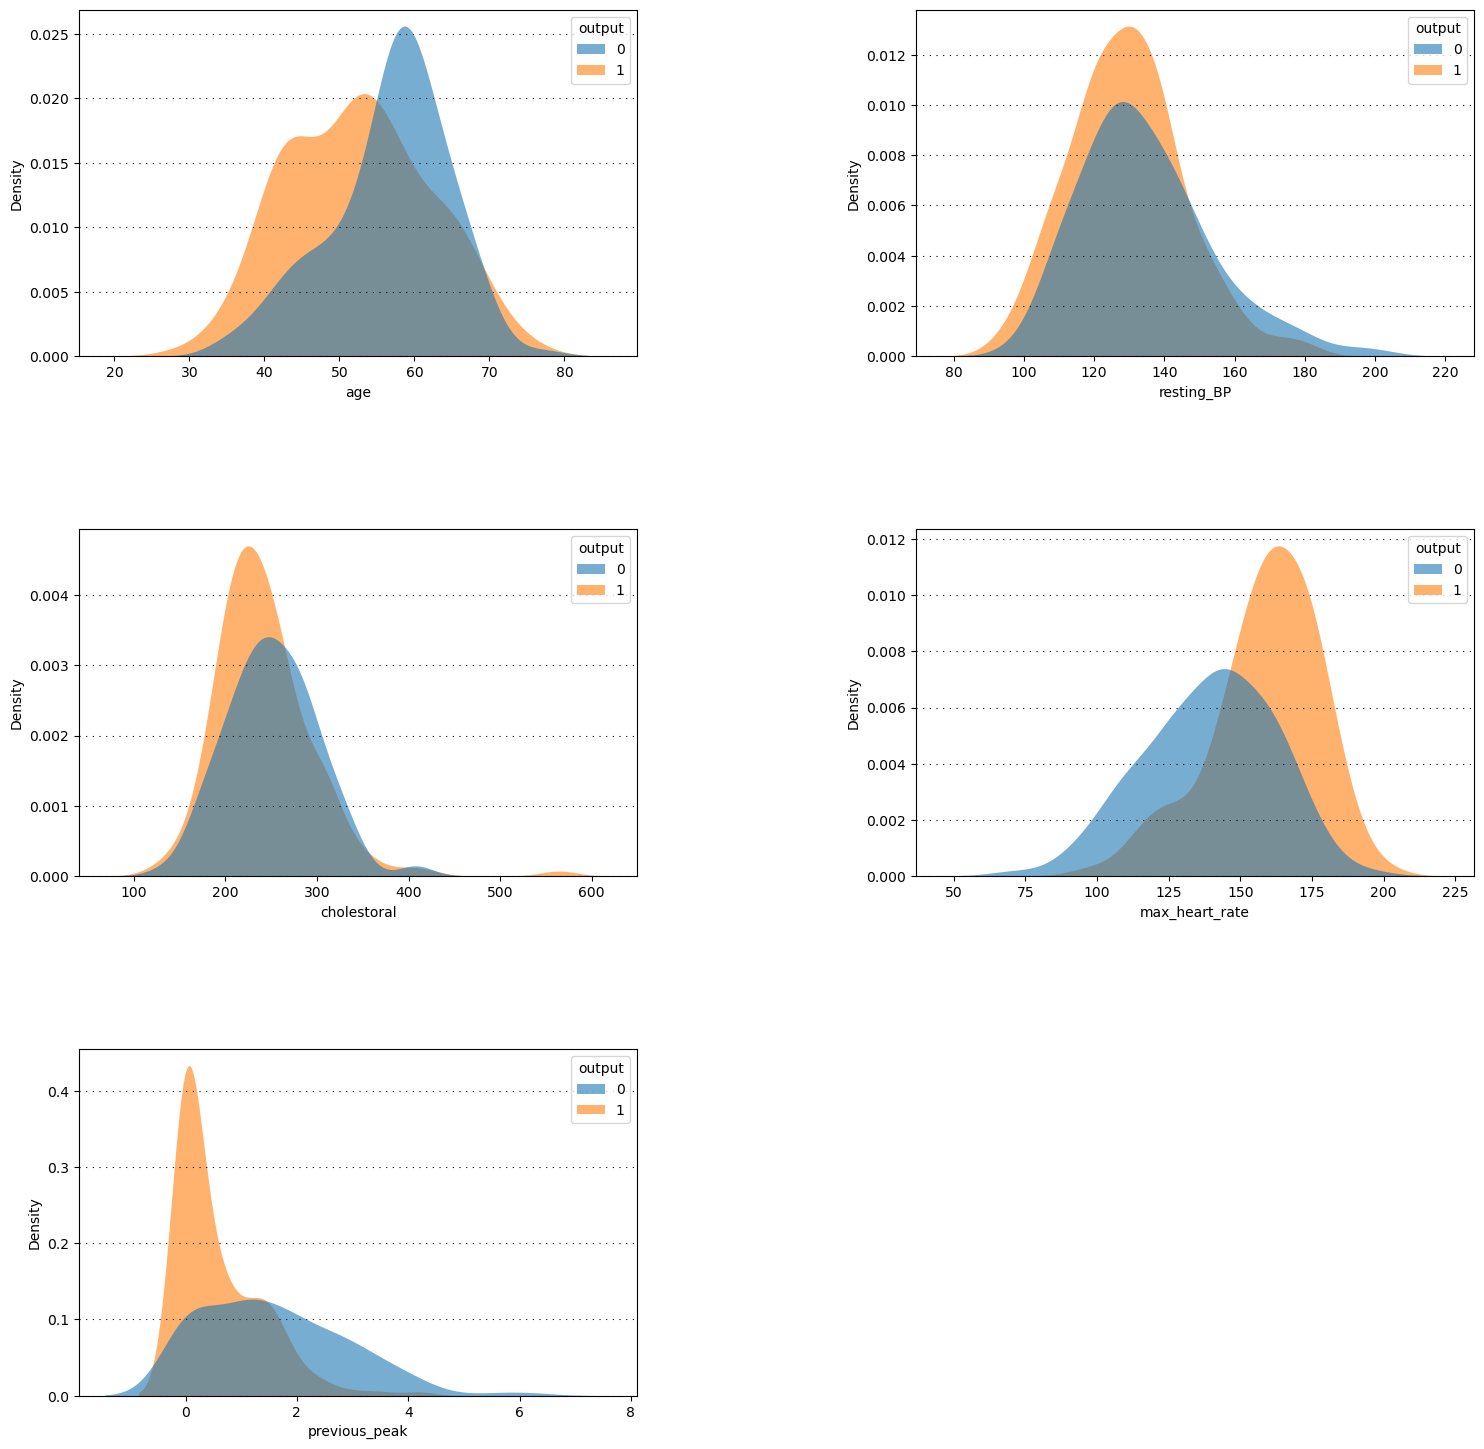

In [12]:
# Distribution of continuous features versus output

# Building the plot
fig = plt.figure(figsize=(18,18))
gs = fig.add_gridspec(3,2)
gs.update(wspace=0.5, hspace=0.5)
ax0 = fig.add_subplot(gs[0,0])
ax1 = fig.add_subplot(gs[0,1])
ax2 = fig.add_subplot(gs[1,0])
ax3 = fig.add_subplot(gs[1,1])
ax4 = fig.add_subplot(gs[2,0])

#age
ax0.grid(color='#000000', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
sns.kdeplot(ax=ax0, data=df, x='age',hue="output", fill=True, alpha=.6, linewidth=0)

#trtbps
ax1.grid(color='#000000', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
sns.kdeplot(ax=ax1, data=df, x='resting_BP',hue="output", fill=True, alpha=.6, linewidth=0)

#chol
ax2.grid(color='#000000', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
sns.kdeplot(ax=ax2, data=df, x='cholestoral',hue="output", fill=True, alpha=.6, linewidth=0)

#thalachh
ax3.grid(color='#000000', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
sns.kdeplot(ax=ax3, data=df, x='max_heart_rate',hue="output", fill=True, alpha=.6, linewidth=0)

#oldpeak
ax4.grid(color='#000000', linestyle=':', axis='y', zorder=0,  dashes=(1,5))
sns.kdeplot(ax=ax4, data=df, x='previous_peak',hue="output", fill=True, alpha=.6, linewidth=0)

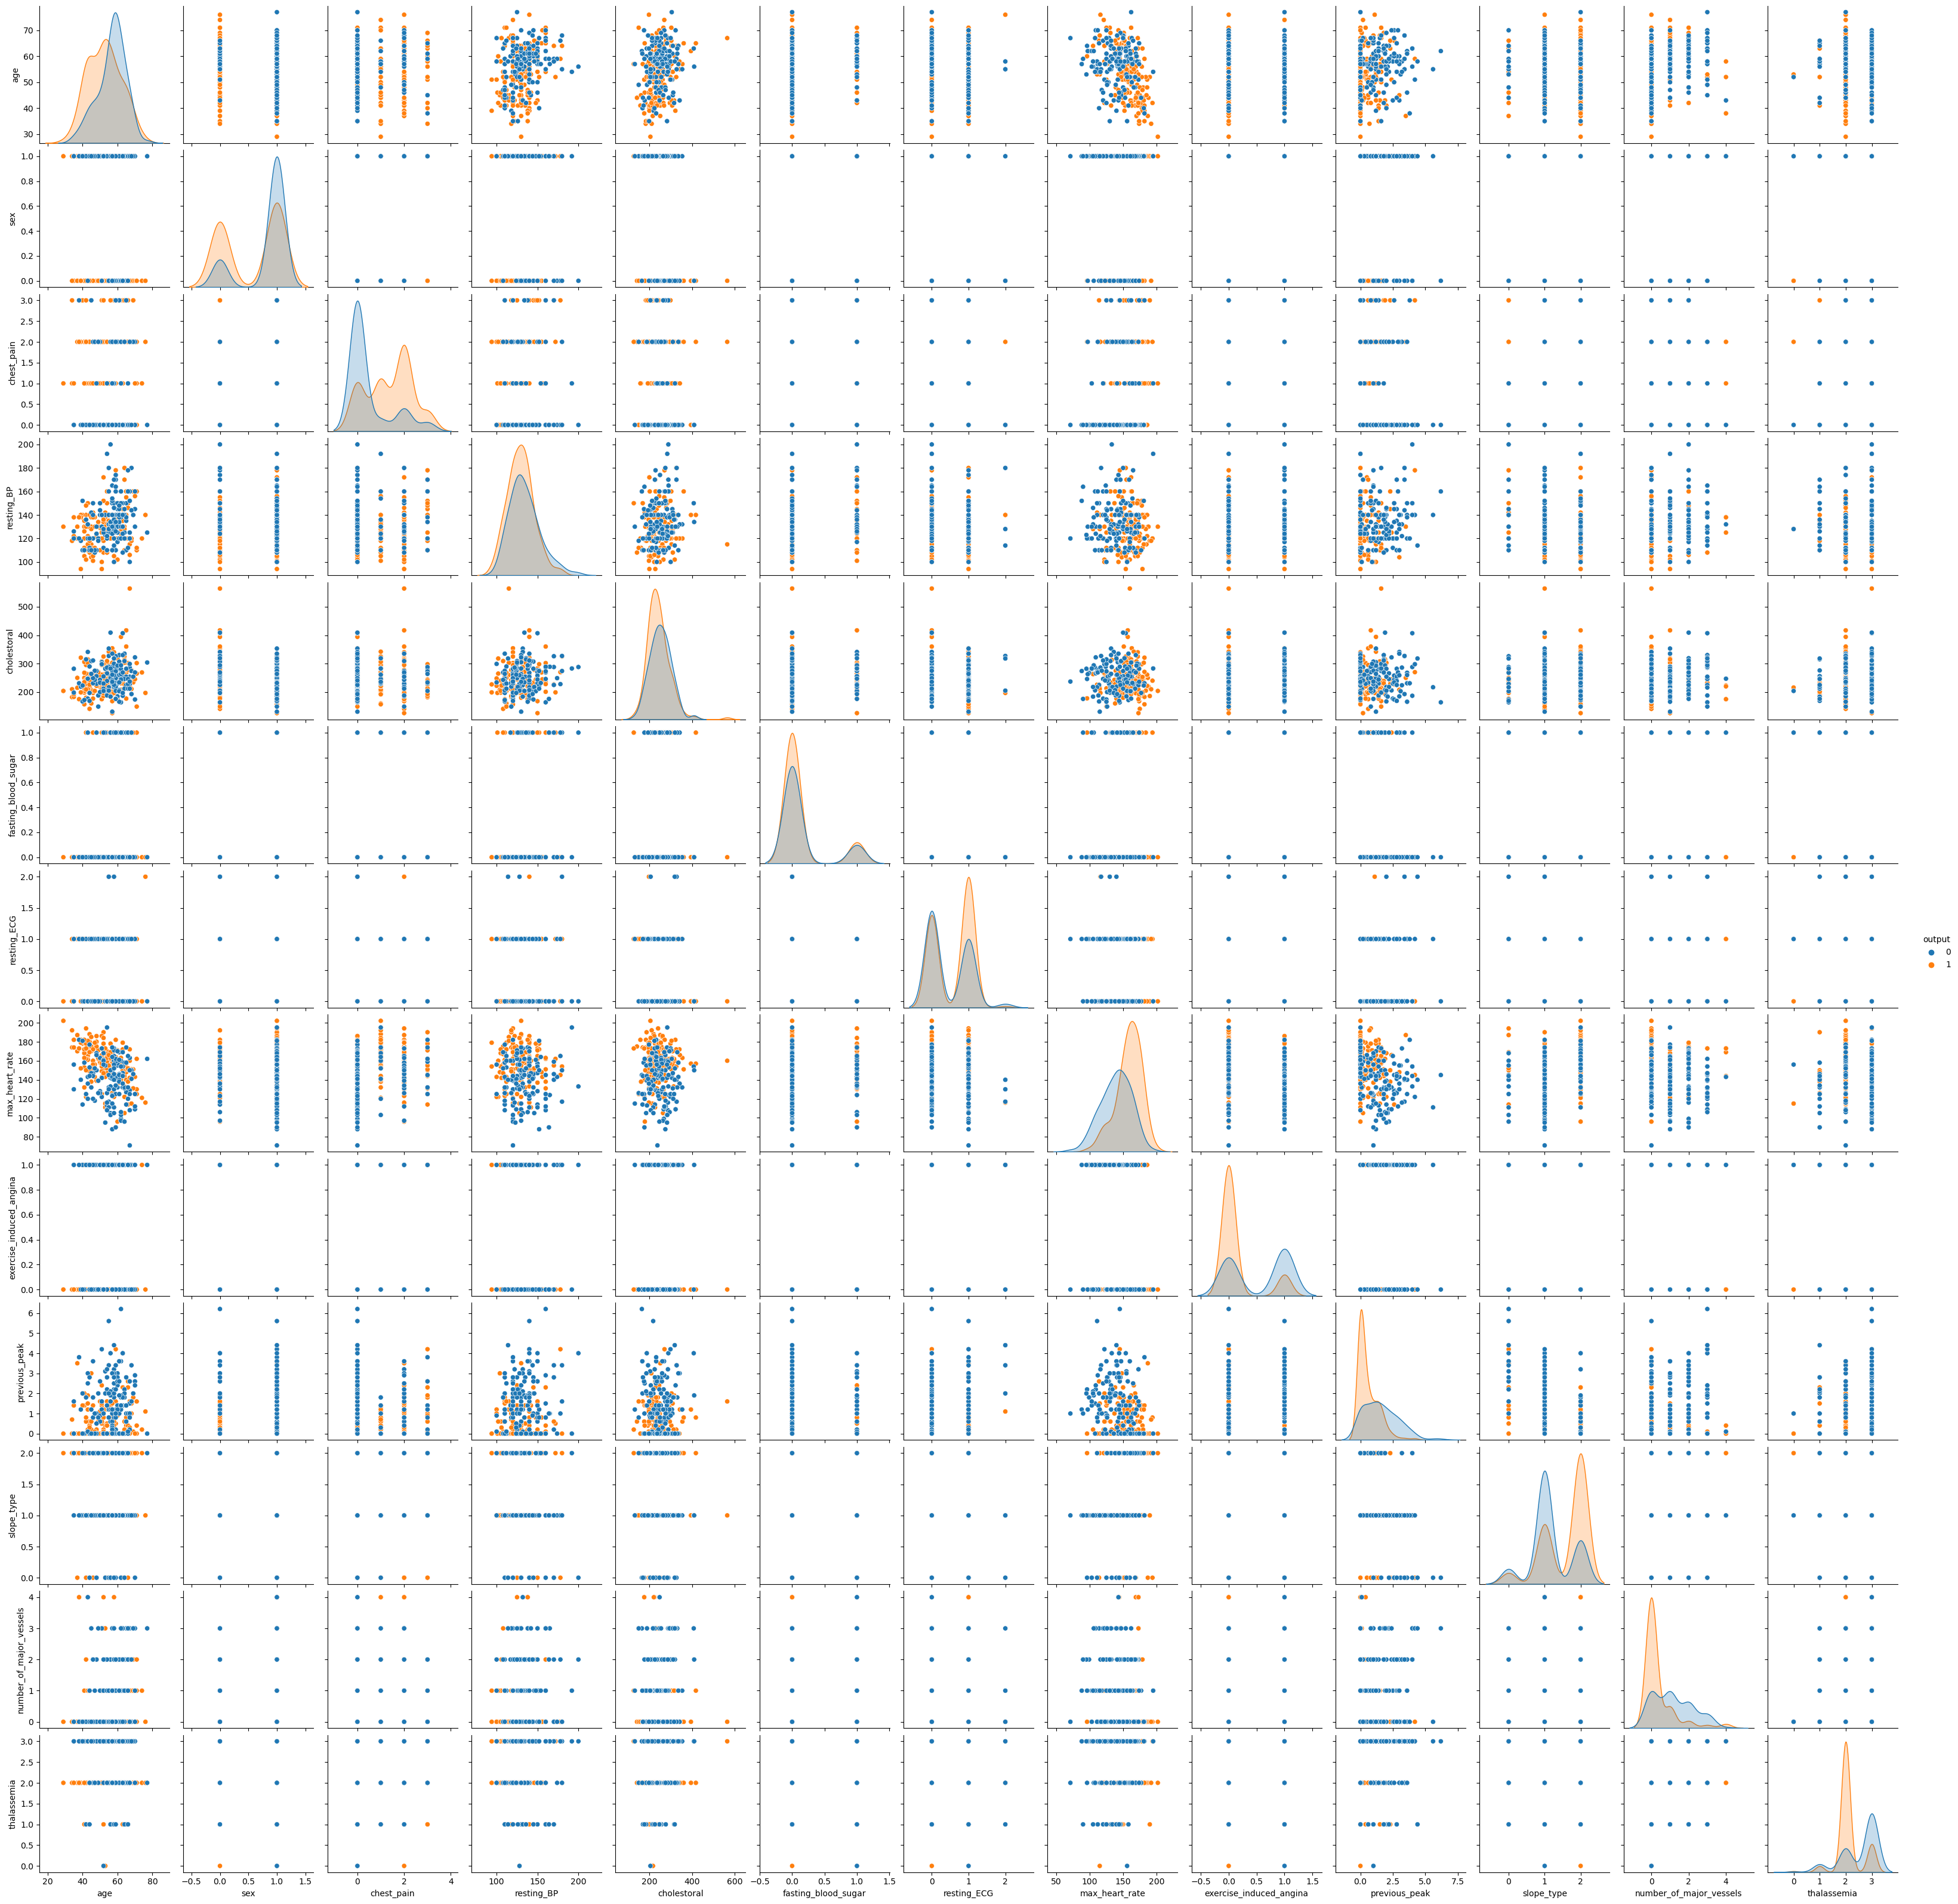

In [13]:
# Pairplot according to output variable
sns.pairplot(df,hue='output')
plt.show()

### Conclusions from the EDA
1. There are no missing values in the data set.
3. The data consists of more than twice the number of males tahn females. This can generate some bias towards the results.
4. There's no apparent/obvious linear correlation between continuous variables.
5. It is common to think that elder people would have higher chances of developing a heart attack but according to the distribution plot of age vs output, that's not the case.
6. Males have higher chances of having a heart attack.
7. oldpeak and slp seems to have a negative relatioship.
8. thalachh and slp seems to have a positive relationship.

# Model Planning and Implementation

In [14]:
# Creating dummies for categorical columns
df = pd.get_dummies(df, columns = categorical, drop_first = True)
df.head()

,age,resting_BP,cholestoral,max_heart_rate,previous_peak,output,sex_1,exercise_induced_angina_1,number_of_major_vessels_1,number_of_major_vessels_2,...,chest_pain_2,chest_pain_3,fasting_blood_sugar_1,resting_ECG_1,resting_ECG_2,slope_type_1,slope_type_2,thalassemia_1,thalassemia_2,thalassemia_3
0,63,145,233,150,2.3,1,1,0,0,0,...,0,1,1,0,0,0,0,1,0,0
1,37,130,250,187,3.5,1,1,0,0,0,...,1,0,0,1,0,0,0,0,1,0
2,41,130,204,172,1.4,1,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
3,56,120,236,178,0.8,1,1,0,0,0,...,0,0,0,1,0,0,1,0,1,0
4,57,120,354,163,0.6,1,0,1,0,0,...,0,0,0,1,0,0,1,0,1,0


In [15]:
# defining the features and target
X = df.drop(['output'], axis = 1)
y = df['output']

In [16]:
# Scaling the continuous features
scaler = RobustScaler()
X[continuous] = scaler.fit_transform(X[continuous])
X.head()

,age,resting_BP,cholestoral,max_heart_rate,previous_peak,sex_1,exercise_induced_angina_1,number_of_major_vessels_1,number_of_major_vessels_2,number_of_major_vessels_3,...,chest_pain_2,chest_pain_3,fasting_blood_sugar_1,resting_ECG_1,resting_ECG_2,slope_type_1,slope_type_2,thalassemia_1,thalassemia_2,thalassemia_3
0,0.592593,0.75,-0.110236,-0.092308,0.9375,1,0,0,0,0,...,0,1,1,0,0,0,0,1,0,0
1,-1.333333,0.00,0.157480,1.046154,1.6875,1,0,0,0,0,...,1,0,0,1,0,0,0,0,1,0
2,-1.037037,0.00,-0.566929,0.584615,0.3750,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
3,0.074074,-0.50,-0.062992,0.769231,0.0000,1,0,0,0,0,...,0,0,0,1,0,0,1,0,1,0
4,0.148148,-0.50,1.795276,0.307692,-0.1250,0,1,0,0,0,...,0,0,0,1,0,0,1,0,1,0


In [17]:
# Train and Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.25, random_state = 42)

# Printing Train and Test shapes
print("X_train: ", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train: ", y_train.shape)
print("y_test: ", y_test.shape)

X_train:  (227, 22)
X_test:  (76, 22)
y_train:  (227,)
y_test:  (76,)


In [18]:
k_folds = KFold(n_splits = 10)
scores = [] # Creating list scores to store results

# Creating list classifiers
classifiers = [
    LogisticRegression(),
    GaussianNB(),
    KNeighborsClassifier(),
    DecisionTreeClassifier(max_depth=5),
    RandomForestClassifier(max_depth=5,n_estimators=100),
    AdaBoostClassifier(),
    XGBClassifier()
]

# Creating function to go through all the classifiers
for classifier in classifiers:
    # Creating pipeline
    pipeline = Pipeline(steps=[
        ("classifiers", classifier)
    ])
    # Calculating scores and mean
    score = cross_val_score(pipeline, X_train, y_train, cv = k_folds)
    scores.append(score.mean())
    # Printing the results
    print('---------------------------------')
    print(classifier)
    print("Cross Validation Scores: ", score)
    print("Average CV Score: ", score.mean())
    print("----------------------------------------------------")

---------------------------------
LogisticRegression()
Cross Validation Scores:  [0.82608696 0.91304348 0.7826087  0.86956522 0.7826087  0.73913043
 0.86956522 0.90909091 0.77272727 0.81818182]
Average CV Score:  0.8282608695652174
----------------------------------------------------
---------------------------------
GaussianNB()
Cross Validation Scores:  [0.86956522 0.69565217 0.7826087  0.69565217 0.52173913 0.69565217
 0.73913043 0.81818182 0.77272727 0.54545455]
Average CV Score:  0.7136363636363636
----------------------------------------------------
---------------------------------
KNeighborsClassifier()
Cross Validation Scores:  [0.7826087  0.69565217 0.86956522 0.7826087  0.69565217 0.82608696
 0.73913043 0.95454545 0.72727273 0.90909091]
Average CV Score:  0.7982213438735177
----------------------------------------------------
---------------------------------
DecisionTreeClassifier(max_depth=5)
Cross Validation Scores:  [0.82608696 0.73913043 0.69565217 0.91304348 0.65217391

# Results Interpretation and Implications

In [19]:
# Fitting the best model
logreg = LogisticRegression()
logreg.fit(X_train,y_train)

# Prediciting
y_pred = logreg.predict(X_test)

<AxesSubplot:xlabel='Predicted', ylabel='Actual'>

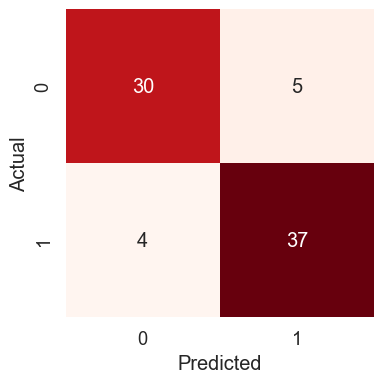

In [20]:
# Confusion Matrix
data = confusion_matrix(y_test, y_pred)
pd_cm = pd.DataFrame(data, 
                     columns = np.unique(y_test), 
                     index = np.unique(y_test))
pd_cm.index.name = 'Actual'
pd_cm.columns.name = 'Predicted'
plt.figure(figsize = (4,4))
sns.set(font_scale=1.2)
sns.heatmap(pd_cm, annot=True, square=True, fmt='d', cbar=False, cmap='Reds')

In [21]:
# Evaluation
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87        35
           1       0.88      0.90      0.89        41

    accuracy                           0.88        76
   macro avg       0.88      0.88      0.88        76
weighted avg       0.88      0.88      0.88        76



In [22]:
# Plotting the prediction vs actual
actual_values = []
predcition_values = []
for i,j in zip(y_test,y_pred):
  actual_values.append(i)
  predcition_values.append(j)
dic = {'Actual':actual_values,
       'Prediction':predcition_values
       }
result  = pd.DataFrame(dic)
import plotly.graph_objects as go
 
fig = go.Figure()
 
 
fig.add_trace(go.Scatter(x=np.arange(0,len(y_test)), y=y_test,
                    mode='markers+lines',
                    name='Test'))
fig.add_trace(go.Scatter(x=np.arange(0,len(y_test)), y=y_pred,
                    mode='markers',
                    name='Pred'))

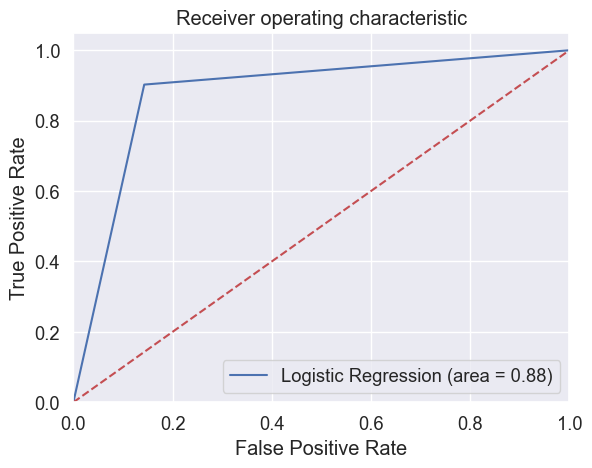

In [23]:
# ROC
rf_roc_auc = roc_auc_score(y_test, y_pred)
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % rf_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.show()

In [24]:
# Feature importance
importances = abs(logreg.coef_[0])
importances

array([0.18257634, 0.23344971, 0.05066065, 0.37550596, 0.77406439,
       0.90259837, 0.84938495, 1.87717672, 1.86577872, 1.18445642,
       0.46832161, 0.29100429, 1.48820465, 1.30312985, 0.17472389,
       0.55352966, 0.07363398, 0.40433674, 0.63044815, 0.16172193,
       0.62236193, 0.83309787])

# Out-of-sample Predictions

In [25]:
# Creating an out of sample dataset based on the original dataset
out_of_sample = X.copy()

# Add noise to the numerical features
numerical_cols = ['age', 'resting_BP', 'cholestoral', 'max_heart_rate', 'previous_peak']
out_of_sample[numerical_cols] += np.random.normal(0, 1, size=(len(out_of_sample), len(numerical_cols)))

# Printing dataset
out_of_sample.head()

,age,resting_BP,cholestoral,max_heart_rate,previous_peak,sex_1,exercise_induced_angina_1,number_of_major_vessels_1,number_of_major_vessels_2,number_of_major_vessels_3,...,chest_pain_2,chest_pain_3,fasting_blood_sugar_1,resting_ECG_1,resting_ECG_2,slope_type_1,slope_type_2,thalassemia_1,thalassemia_2,thalassemia_3
0,0.934169,1.450917,-1.590287,-2.152063,1.488908,1,0,0,0,0,...,0,1,1,0,0,0,0,1,0,0
1,-0.181851,0.225465,-0.334795,-0.049093,1.684782,1,0,0,0,0,...,1,0,0,1,0,0,0,0,1,0
2,-0.635798,-0.329905,-1.653535,1.221357,1.128409,0,0,0,0,0,...,0,0,0,0,0,0,1,0,1,0
3,0.316888,0.395934,0.556104,0.998443,-0.077598,1,0,0,0,0,...,0,0,0,1,0,0,1,0,1,0
4,-0.553615,-0.120055,3.224630,-1.254413,1.273633,0,1,0,0,0,...,0,0,0,1,0,0,1,0,1,0


In [26]:
# Dropping target variable
X_outofsample = out_of_sample
y = df['output']

# Make predictions on the augmented data
y_pred_outofsample = logreg.predict(X_outofsample)

<AxesSubplot:xlabel='Predicted', ylabel='Actual'>

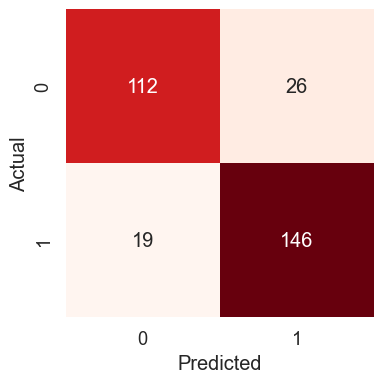

In [27]:
# Confusion Matrix
data = confusion_matrix(y, y_pred_outofsample)
pd_cm = pd.DataFrame(data, 
                     columns = np.unique(y_test), 
                     index = np.unique(y_test))
pd_cm.index.name = 'Actual'
pd_cm.columns.name = 'Predicted'
plt.figure(figsize = (4,4))
sns.set(font_scale=1.2)
sns.heatmap(pd_cm, annot=True, square=True, fmt='d', cbar=False, cmap='Reds')

In [28]:
# Accuracy
# Calculate the accuracy score and confusion matrix
accuracy = accuracy_score(y, y_pred_outofsample)
print('Accuracy score on out of sample data:', accuracy)

Accuracy score on out of sample data: 0.8514851485148515


In [29]:
# Evaluation
print(classification_report(y,y_pred_outofsample))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83       138
           1       0.85      0.88      0.87       165

    accuracy                           0.85       303
   macro avg       0.85      0.85      0.85       303
weighted avg       0.85      0.85      0.85       303



In [30]:
# print predictions
print(y_pred_outofsample)

[0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1
 0 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 0 1 1 0 1 1 1 1 0 1 1 1 1
 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1
 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 0 1 0 0
 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1
 0 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0 0
 1 0 0 1 0 0 1]


# Group Evaluation
| Evaluator/Evaluatee | Gustavo | Haichuan | Yuen | Chisa| Xinyu |
|---------------------|---------|----------|------|------|-------|
|       Gustavo       |    -    |     4    |   4  |   4  |   4   |
|       Haichuan      |    4    |     -    |   4  |   4  |   4   |
|         Yeun        |    4    |     4    |   -  |   4  |   4   |
|        Chisa        |    4    |     4    |   4  |   -  |   4   |
|        Xinyu        |    4    |     4    |   4  |   4  |   -   |